In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
topics = ["Social Anxiety", "Dating", "Career", "Fitness", "Mental Health"]

data = []

for i in range(100):
    topic = random.choice(topics)
    
    # Create realistic pattern
    if topic == "Mental Health":
        shares = random.randint(100, 300)
    else:
        shares = random.randint(10, 150)
    
    likes = random.randint(100, 1000)
    saves = random.randint(20, 200)

    data.append([
        i+1,
        topic,
        likes,
        shares,
        saves,
        random.choice(["Short", "Long"]),
        random.choice(["Morning", "Afternoon", "Night"])
    ])

df = pd.DataFrame(data, columns=[
    "Post_ID", "Topic", "Likes", "Shares", "Saves",
    "Content_Type", "Post_Time"
])

df.head()

,Post_ID,Topic,Likes,Shares,Saves,Content_Type,Post_Time
0,1,Mental Health,423,219,102,Short,Night
1,2,Mental Health,874,102,46,Short,Night
2,3,Dating,931,80,173,Short,Morning
3,4,Fitness,801,115,196,Short,Afternoon
4,5,Mental Health,854,104,110,Long,Night


In [3]:
df["Engagement"] = df["Likes"] + df["Shares"] + df["Saves"]

df["Share_Rate"] = df["Shares"] / df["Likes"]
df["Save_Rate"] = df["Saves"] / df["Likes"]

df["High_Engagement"] = (df["Engagement"] > df["Engagement"].mean()).astype(int)

df.head()

,Post_ID,Topic,Likes,Shares,Saves,Content_Type,Post_Time,Engagement,Share_Rate,Save_Rate,High_Engagement
0,1,Mental Health,423,219,102,Short,Night,744,0.517730,0.241135,0
1,2,Mental Health,874,102,46,Short,Night,1022,0.116705,0.052632,1
2,3,Dating,931,80,173,Short,Morning,1184,0.085929,0.185822,1
3,4,Fitness,801,115,196,Short,Afternoon,1112,0.143571,0.244694,1
4,5,Mental Health,854,104,110,Long,Night,1068,0.121780,0.128806,1


               Likes    Shares     Saves  Engagement
Likes       1.000000 -0.076375  0.110143    0.941792
Shares     -0.076375  1.000000 -0.020702    0.187089
Saves       0.110143 -0.020702  1.000000    0.312624
Engagement  0.941792  0.187089  0.312624    1.000000


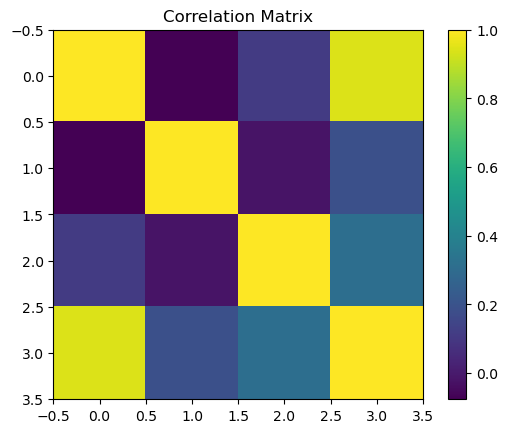

In [21]:
corr = df[["Likes", "Shares", "Saves", "Engagement"]].corr()
print(corr)

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

In [22]:
df["Viral_Score"] = (
    0.5 * df["Share_Rate"] +
    0.3 * df["Save_Rate"] +
    0.2 * (df["Likes"] / df["Likes"].max())
) * 100

df[["Post_ID", "Viral_Score"]].head()

,Post_ID,Viral_Score
0,1,20.324920
1,2,26.226843
2,3,41.001159
3,4,26.728079
4,5,23.274409


In [23]:
def simple_model(row):
    score = (
        0.6 * row["Share_Rate"] +
        0.3 * row["Save_Rate"] +
        0.1 * (row["Likes"] / 1000)
    )
    return 1 if score > 0.5 else 0

df["Predicted_Engagement"] = df.apply(simple_model, axis=1)

df[["High_Engagement", "Predicted_Engagement"]].head()

,High_Engagement,Predicted_Engagement
0,0,0
1,1,0
2,0,0
3,1,0
4,1,0


In [24]:
accuracy = (df["High_Engagement"] == df["Predicted_Engagement"]).mean()

print("Model Accuracy:", accuracy)

Model Accuracy: 0.42


In [25]:
short = df[df["Content_Type"] == "Short"]["Engagement"]
long = df[df["Content_Type"] == "Long"]["Engagement"]

mean_diff = short.mean() - long.mean()

std_error = np.sqrt((short.var()/len(short)) + (long.var()/len(long)))

z_score = mean_diff / std_error

print("Z-Score:", z_score)

if abs(z_score) > 1.96:
    print("Significant Difference (95% confidence)")
else:
    print("No Significant Difference")

Z-Score: 1.1492704569734404
No Significant Difference


In [26]:
score_table = df.groupby("Topic").agg({
    "Viral_Score": "mean",
    "Engagement": "mean"
})

score_table["Final_Score"] = (
    0.6 * score_table["Viral_Score"] +
    0.4 * score_table["Engagement"]
)

best_topic = score_table["Final_Score"].idxmax()

print(score_table)
print("\nBest Topic:", best_topic)

                Viral_Score  Engagement  Final_Score
Topic                                               
Career            30.031668  717.560000   305.043001
Dating            24.378018  726.750000   305.326811
Fitness           26.233852  804.666667   337.606978
Mental Health     51.443989  717.736842   317.961130
Social Anxiety    29.485193  694.055556   295.313338

Best Topic: Fitness


In [27]:
trend = df.groupby("Topic")["Shares"].sum().sort_values(ascending=False)

trend

Topic
Mental Health     3804
Career            2062
Dating            1403
Fitness           1366
Social Anxiety    1235
Name: Shares, dtype: int64

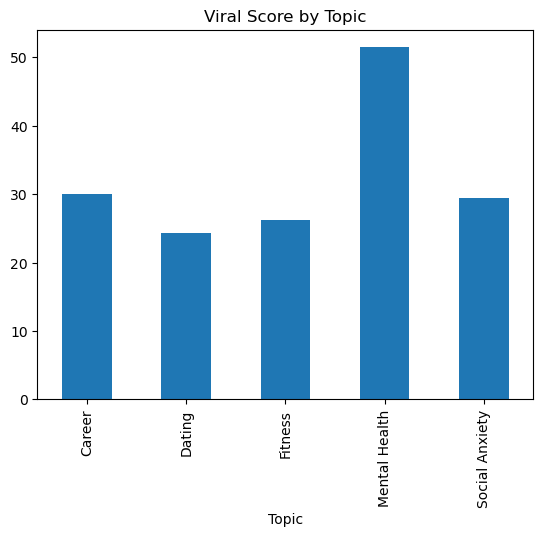

In [28]:
# Viral Score
plt.figure()
df.groupby("Topic")["Viral_Score"].mean().plot(kind='bar')
plt.title("Viral Score by Topic")
plt.show()

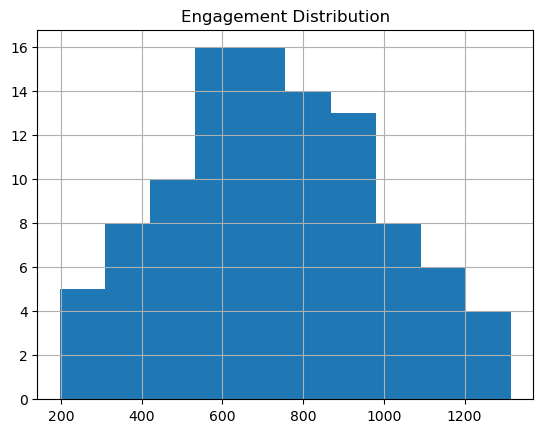

In [29]:
# Engagement Distribution
plt.figure()
df["Engagement"].hist()
plt.title("Engagement Distribution")
plt.show()

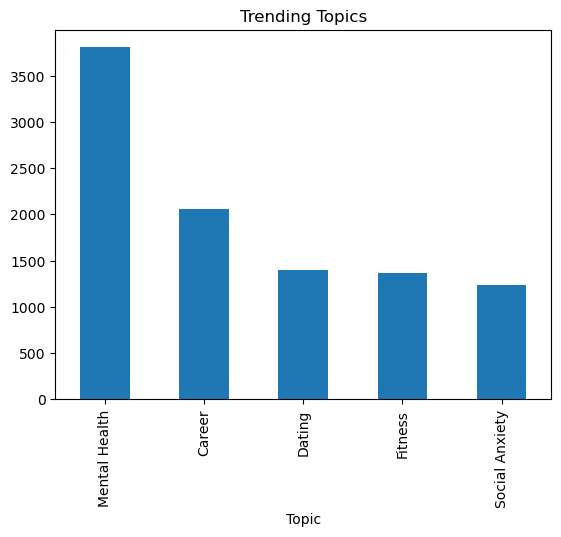

In [30]:
# Trend Visualization
plt.figure()
trend.plot(kind='bar')
plt.title("Trending Topics")
plt.show()

In [31]:
print("=========== FINAL REPORT ===========")

print("🔥 Best Topic:", best_topic)
print("📈 Trending Topic:", trend.index[0])
print("🤖 Model Accuracy:", accuracy)

if abs(z_score) > 1.96:
    print("📊 A/B Test Result: Significant Difference")
else:
    print("📊 A/B Test Result: No Significant Difference")

=========== FINAL REPORT ===========
🔥 Best Topic: Fitness
📈 Trending Topic: Mental Health
🤖 Model Accuracy: 0.42
📊 A/B Test Result: No Significant Difference
